In [1]:
from nmmlab.wilson_cowan import wilco_unforced, wilco_forced, wilco_network, sigmoid
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [2]:
#PARAMETERS 
tau_x = 8.0
tau_y = 8.0
w_xx  = 16.0
w_xy  = 12.0
w_yx  = 15.0
w_yy  = 3.0
x0    = [0.1, 0.05]
A     = 0.05
f     = 24.0

t      = np.linspace(0, 500, 50000)
t_long = np.linspace(0, 2000, 100000)
dt     = t_long[1] - t_long[0]

# network parameters
N   = 3
G   = 2.0
Px  = np.array([1.5, 1.5, 0.9])
rng = np.random.default_rng(42)
C = rng.random((N, N))
np.fill_diagonal(C, 0)
eigvals = np.linalg.eigvals(C)
C /= np.max(np.abs(eigvals))
x0_net = np.concatenate([rng.random(N) * 0.1, rng.random(N) * 0.05])
colors = ['blue', 'orange', 'green']





[None, None, None, None, None, None, None, None, None]

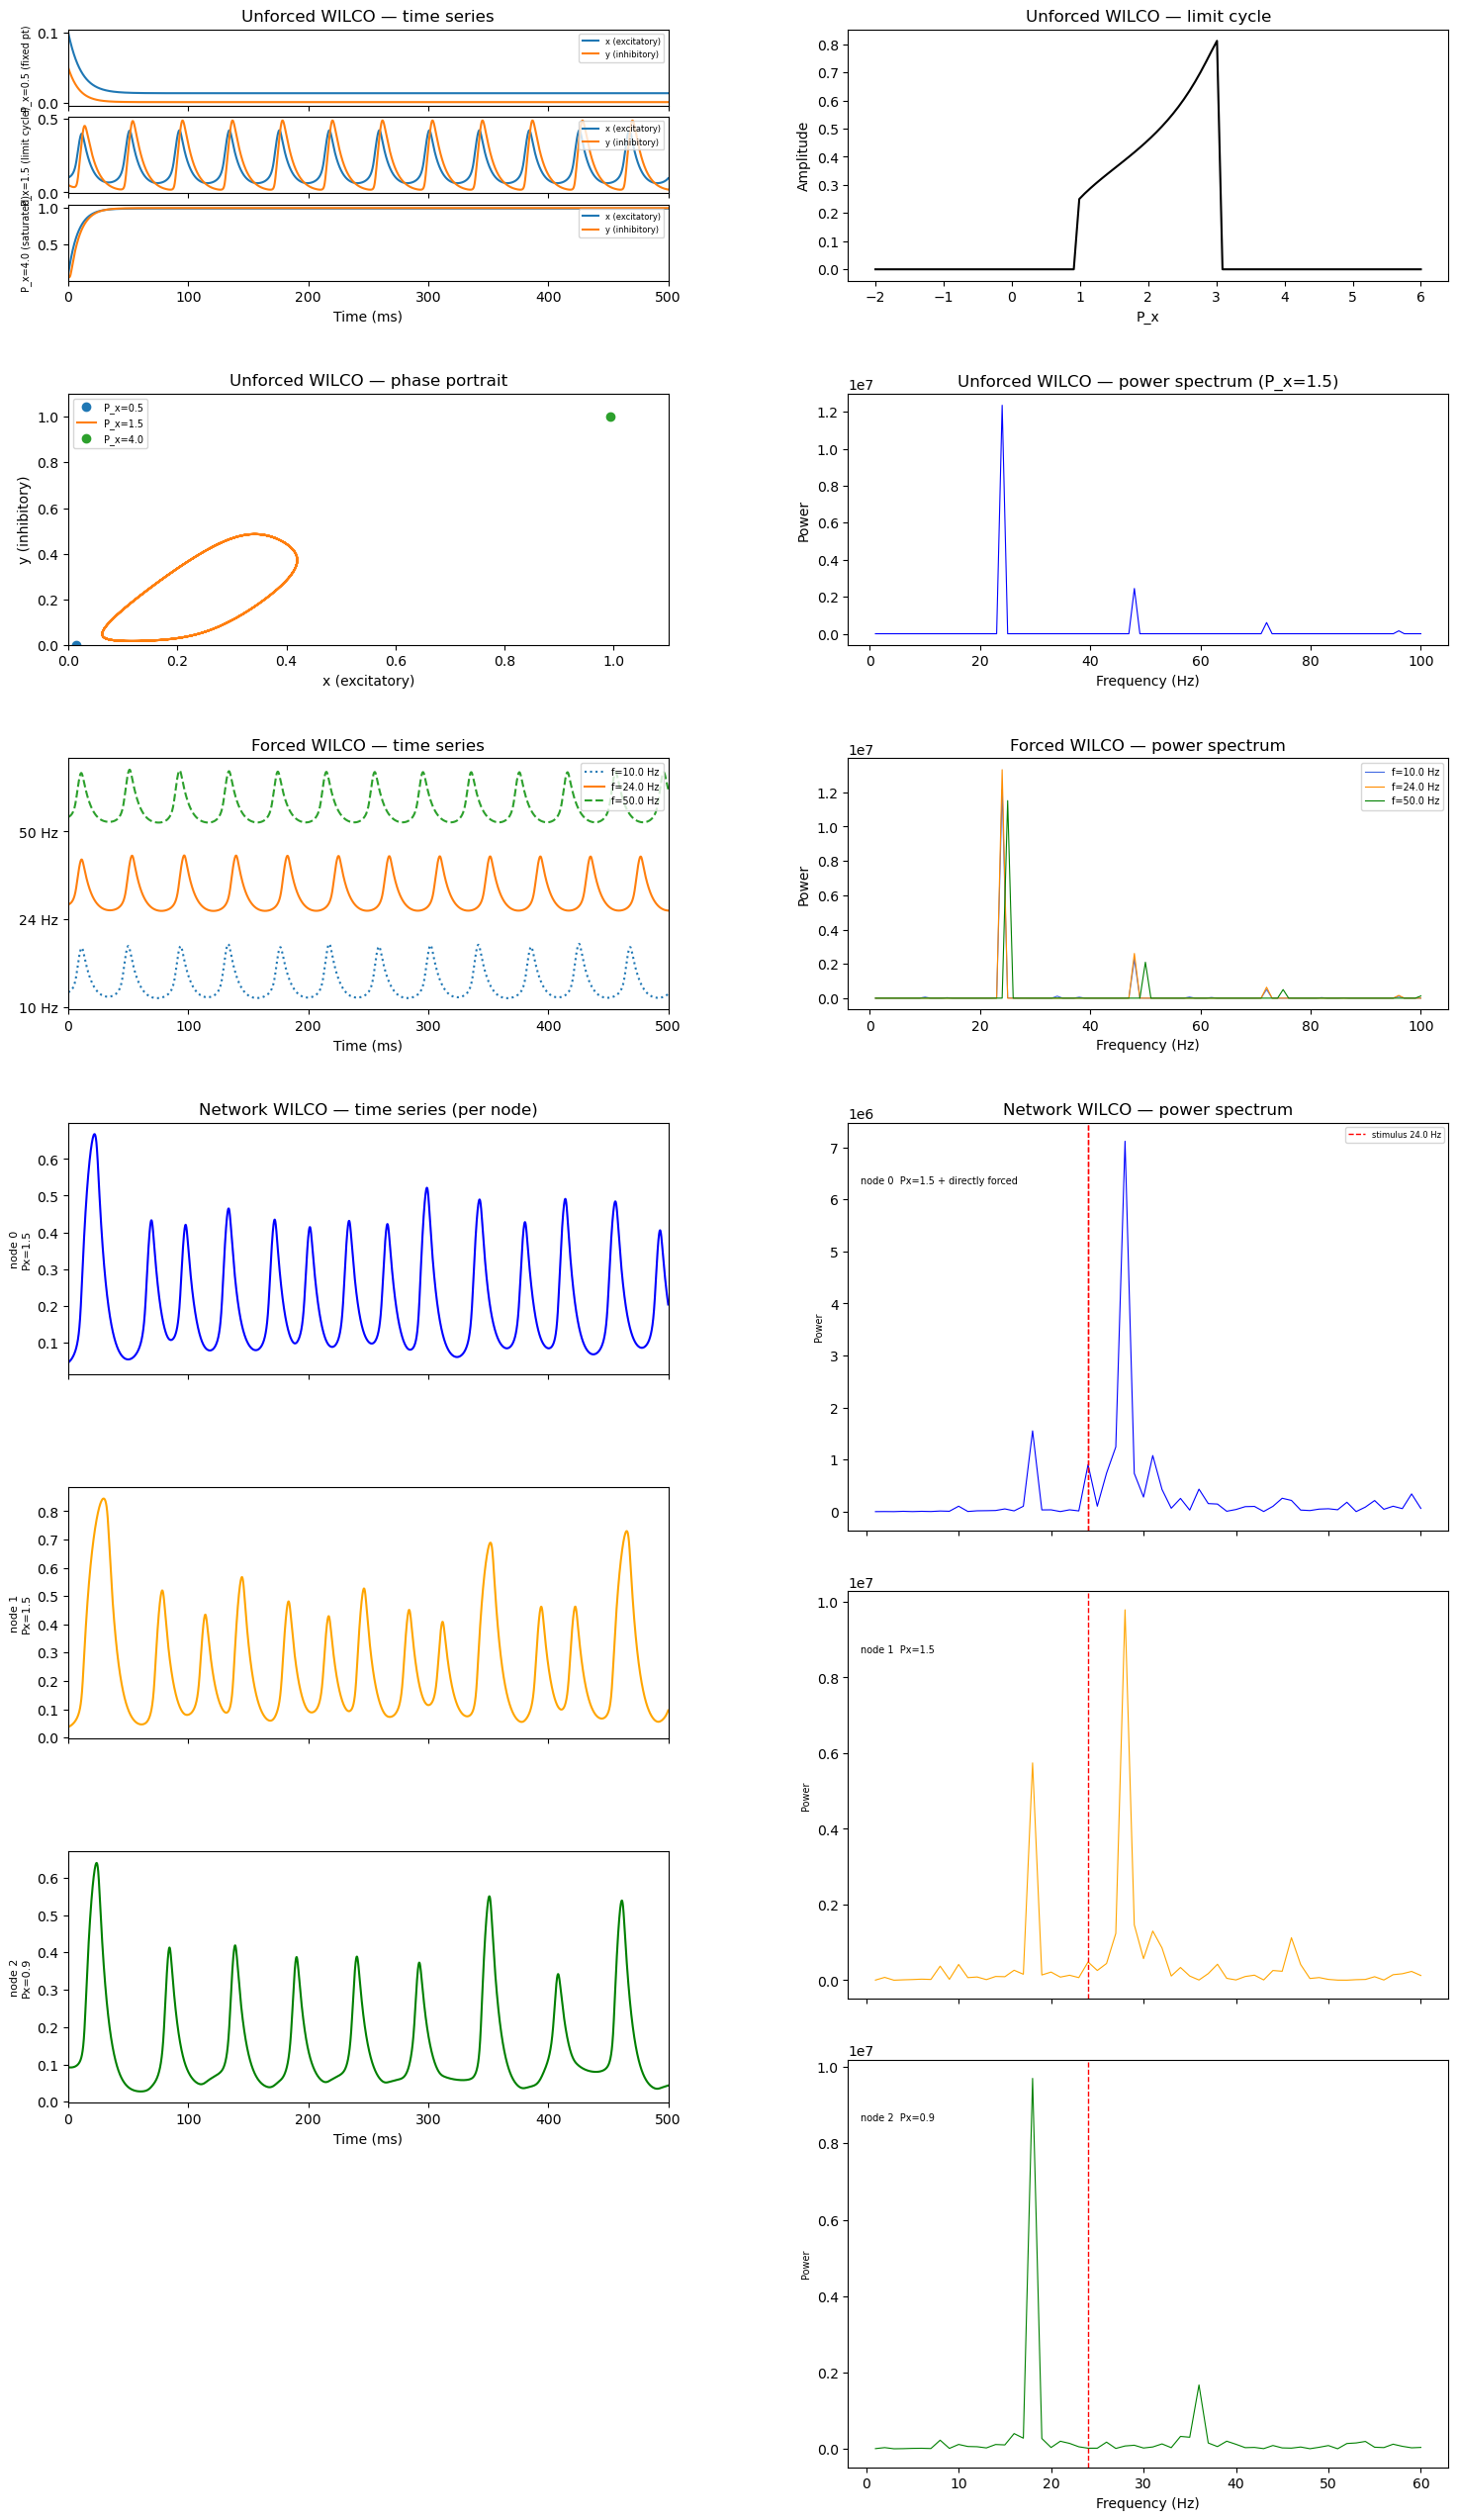

In [6]:
fig = plt.figure(figsize=(18, 32))
gs  = gridspec.GridSpec(7, 2, figure=fig, hspace=0.45, wspace=0.3)

gs_unforced = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[0, 0], hspace=0.15)
ax1a = fig.add_subplot(gs_unforced[0])
ax1b = fig.add_subplot(gs_unforced[1], sharex=ax1a)
ax1c = fig.add_subplot(gs_unforced[2], sharex=ax1a)
ax2 = fig.add_subplot(gs[0, 1])   # bifurcation
ax3 = fig.add_subplot(gs[1, 0])   # phase portrait
ax4 = fig.add_subplot(gs[1, 1])   # power spectrum
ax5 = fig.add_subplot(gs[2, 0])   # forced time series
ax6 = fig.add_subplot(gs[2, 1])   # forced power spectrum
# row 3 left: 3 stacked network node plots sharing x-axis
ax7a = fig.add_subplot(gs[3, 0])
ax7b = fig.add_subplot(gs[4, 0], sharex=ax7a)
ax7c = fig.add_subplot(gs[5, 0], sharex=ax7a)
gs_psd = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[3:, 1], hspace=0.15)
ax8a = fig.add_subplot(gs_psd[0])
ax8b = fig.add_subplot(gs_psd[1], sharex=ax8a)
ax8c = fig.add_subplot(gs_psd[2], sharex=ax8a)

# ── Row 1: Unforced time series ──
for ax, P_x, label in zip([ax1a, ax1b, ax1c],
                            [0.5, 1.5, 4.0],
                            ['P_x=0.5 (fixed pt)', 'P_x=1.5 (limit cycle)', 'P_x=4.0 (saturated)']):
    sol = wilco_unforced(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, P_x, x0, t)
    ax.plot(t, sol[0], label='x (excitatory)')
    ax.plot(t, sol[1], label='y (inhibitory)')
    ax.set_ylabel(label, fontsize=7)
    ax.legend(fontsize=6, loc='upper right')
    ax.set_xlim(0, 500)

ax1a.set_title('Unforced WILCO — time series')
ax1c.set_xlabel('Time (ms)')
plt.setp(ax1a.get_xticklabels(), visible=False)
plt.setp(ax1b.get_xticklabels(), visible=False)

# ── Row 1: Bifurcation ──
P_x_values = np.linspace(-2, 6, 100)
amplitudes  = []
for P_x in P_x_values:
    sol   = wilco_unforced(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, P_x, x0, t)
    x_end = sol[0, -len(t)//5:]
    amplitudes.append(x_end.max() - x_end.min())
ax2.plot(P_x_values, amplitudes, 'k-')
ax2.set_title('Unforced WILCO — limit cycle')
ax2.set_xlabel('P_x')
ax2.set_ylabel('Amplitude')

# ── Row 2: Phase portrait ──
for P_x, ls, label in zip([0.5, 1.5, 4.0], [':', '-', '--'],
                           ['P_x=0.5', 'P_x=1.5', 'P_x=4.0']):
    sol   = wilco_unforced(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, P_x, x0, t_long)
    n     = len(t_long) // 10
    x_end, y_end = sol[0, -n:], sol[1, -n:]
    if x_end.max() - x_end.min() > 1e-3:
        ax3.plot(x_end, y_end, ls, label=label)
    else:
        ax3.plot(x_end[-1], y_end[-1], 'o', label=label)
ax3.set_xlim(0, 1.1); ax3.set_ylim(0, 1.1)
ax3.set_title('Unforced WILCO — phase portrait')
ax3.set_xlabel('x (excitatory)'); ax3.set_ylabel('y (inhibitory)')
ax3.legend(fontsize=7)

# ── Row 2: Power spectrum ──
sol      = wilco_unforced(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, 1.5, x0, t_long)
n        = len(t_long) // 2
x_steady = sol[0, -n:] - np.mean(sol[0, -n:])
freqs    = np.fft.rfftfreq(len(x_steady), d=dt/1000)
power    = np.abs(np.fft.rfft(x_steady))**2
mask     = (freqs > 0) & (freqs <= 100)
ax4.plot(freqs[mask], power[mask], 'b-', linewidth=0.8)
ax4.set_title('Unforced WILCO — power spectrum (P_x=1.5)')
ax4.set_xlabel('Frequency (Hz)'); ax4.set_ylabel('Power')

# ── Row 3: Forced time series (offset) ──
offsets = [0, 0.6, 1.2]
for f_stim, ls, offset in zip([10.0, 24.0, 50.0], [':', '-', '--'], offsets):
    sol = wilco_forced(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, 1.5, A, f_stim, x0, t)
    ax5.plot(t, sol[0] + offset, ls, label=f'f={f_stim} Hz')
ax5.set_xlim(0, 500)
ax5.set_yticks(offsets); ax5.set_yticklabels(['10 Hz', '24 Hz', '50 Hz'])
ax5.set_title('Forced WILCO — time series')
ax5.set_xlabel('Time (ms)')
ax5.legend(fontsize=7)

# ── Row 3: Forced power spectrum ──
for f_stim, color in zip([10.0, 24.0, 50.0], ['royalblue', 'darkorange', 'green']):
    sol      = wilco_forced(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, 1.5, A, f_stim, x0, t_long)
    x_steady = sol[0, -n:] - np.mean(sol[0, -n:])
    freqs    = np.fft.rfftfreq(len(x_steady), d=dt/1000)
    power    = np.abs(np.fft.rfft(x_steady))**2
    mask     = (freqs > 0) & (freqs <= 100)
    ax6.plot(freqs[mask], power[mask], color=color, linewidth=0.8, label=f'f={f_stim} Hz')
ax6.set_title('Forced WILCO — power spectrum')
ax6.set_xlabel('Frequency (Hz)'); ax6.set_ylabel('Power')
ax6.legend(fontsize=7)

# ── Rows 4-6: Network time series (stacked) ──
sol_net = wilco_network(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, Px, G, C, A, f, x0_net, t)
for ax, i in zip([ax7a, ax7b, ax7c], range(N)):
    ax.plot(t, sol_net[i], color=colors[i])
    ax.set_ylabel(f'node {i}\nPx={Px[i]}', fontsize=8)
    ax.set_xlim(0, 500)
ax7a.set_title('Network WILCO — time series (per node)')
ax7c.set_xlabel('Time (ms)')
plt.setp(ax7a.get_xticklabels(), visible=False)
plt.setp(ax7b.get_xticklabels(), visible=False)

# ── Network power spectrum ──
sol_net2 = wilco_network(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, Px, G, C, A, f, x0_net, t_long)
for ax, i, label in zip([ax8a, ax8b, ax8c], range(N),
                         [f'node 0  Px={Px[0]} + directly forced', f'node 1  Px={Px[1]}', f'node 2  Px={Px[2]}']):
    x_steady = sol_net2[i, -n:] - np.mean(sol_net2[i, -n:])
    freqs = np.fft.rfftfreq(len(x_steady), d=dt/1000)
    power = np.abs(np.fft.rfft(x_steady))**2
    mask  = (freqs > 0) & (freqs <= 60)
    ax.plot(freqs[mask], power[mask], color=colors[i], linewidth=0.8)
    ax.axvline(f, color='r', linestyle='--', linewidth=1.0)
    ax.set_ylabel('Power', fontsize=7)
    ax.text(0.02, 0.85, label, transform=ax.transAxes, fontsize=7)

ax8a.set_title('Network WILCO — power spectrum')
ax8a.axvline(f, color='r', linestyle='--', linewidth=1.0, label=f'stimulus {f} Hz')
ax8a.legend(fontsize=6, loc='upper right')
ax8c.set_xlabel('Frequency (Hz)')
plt.setp(ax8a.get_xticklabels(), visible=False)
plt.setp(ax8b.get_xticklabels(), visible=False)


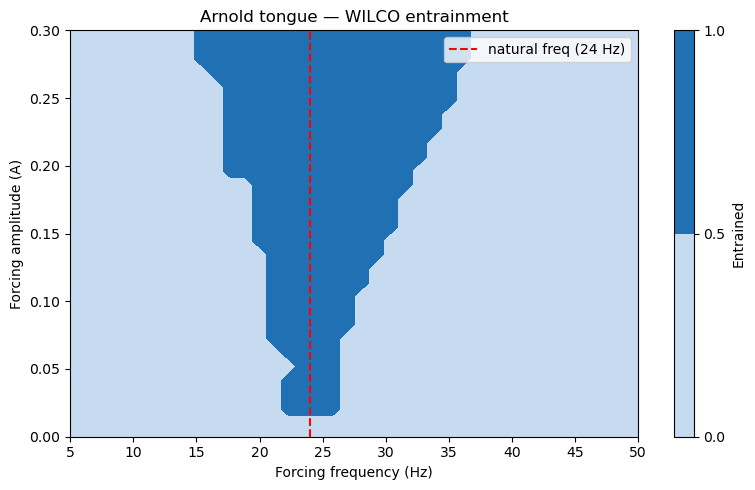

In [4]:
f_values = np.linspace(5, 50, 40)
A_values = np.linspace(0, 0.3, 30)
t_at = np.linspace(0, 800, 16000)   # a bit longer
dt_at = t_at[1] - t_at[0]
n_at  = len(t_at) // 2

entrained = np.zeros((len(A_values), len(f_values)))

for i, A_val in enumerate(A_values):
    for j, f_val in enumerate(f_values):
        sol = wilco_forced(tau_x, tau_y, w_xx, w_xy, w_yx, w_yy, 1.5,
                           A_val, f_val, x0, t_at)
        x_ss = sol[0, -n_at:] - np.mean(sol[0, -n_at:])
        freqs = np.fft.rfftfreq(len(x_ss), d=dt_at/1000)
        power = np.abs(np.fft.rfft(x_ss))**2
        mask  = freqs > 0
        f_peak = freqs[mask][np.argmax(power[mask])]
        entrained[i, j] = (abs(f_peak - f_val) < 1.5) and (A_val > 0.02)

plt.figure(figsize=(8, 5))
plt.contourf(f_values, A_values, entrained, levels=1, cmap='Blues')
plt.axvline(24, color='r', linestyle='--', label='natural freq (24 Hz)')
plt.xlabel('Forcing frequency (Hz)')
plt.ylabel('Forcing amplitude (A)')
plt.title('Arnold tongue — WILCO entrainment')
plt.colorbar(label='Entrained')
plt.legend()
plt.tight_layout()
plt.show()

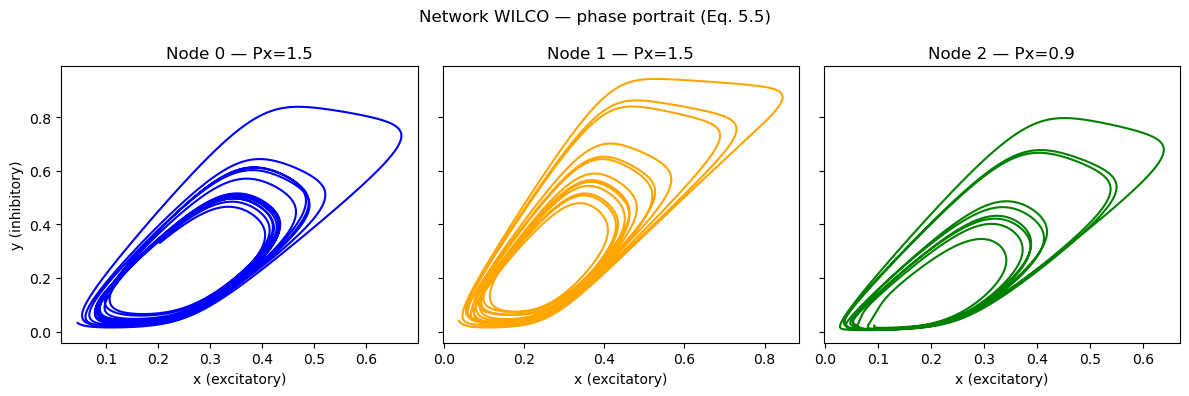

In [5]:
fig, axes = plt.subplots(1, N, figsize=(12, 4), sharey=True)

for i in range(N):
    x_i = sol_net[i]        # excitatory
    y_i = sol_net[N + i]    # inhibitory
    axes[i].plot(x_i, y_i, color=colors[i])
    axes[i].set_title(f'Node {i} — Px={Px[i]}')
    axes[i].set_xlabel('x (excitatory)')

axes[0].set_ylabel('y (inhibitory)')
fig.suptitle('Network WILCO — phase portrait (Eq. 5.5)')
plt.tight_layout()
plt.show()